In [1]:
from lotka_volterra_UDE_case_study.mod import Func, Func1D
import jax.random as jrandom
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pymob.simulation import SimulationBase
from pymob.solvers.diffrax import JaxSolver, UDESolver
from pymob.sim.config import Param
import diffrax
import jax.random as jr
import jax

# jax.config.update('jax_enable_x64', True)

c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\sympy2jax\sympy_module.py:290: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  has_extra_funcs: bool = eqx.static_field()


method to create artificial data

In [2]:
def _get_data(ts, theta, max, min, noisiness, *, key):
    """
    Returns a single time series (evaluated at the time points defined by ts) of the 
    Lotka-Volterra model with some normally-distributed noise. Initial conditions for 
    prey and predator are both chosen randomly from the range [min, max].

    Parameters
    ----------
    ts : jax.ArrayImpl
        An array containing all the time points the timeseries should be evaluated for.
    theta : list
        A list of four floats representing the parameters of the Lotka Volterra model
        [alpha, beta, gamma, delta].
    max : float
        Maximum value for the initial prey and predator values (before adding noise).
    min : float
        Minimum value for the initial prey and predator values (before adding noise).
    noisiness : float
        Scale of the normal distribution the noise is drawn from. I fnoisiness == 0,
        no noise is added.
    key : jax.ArrayImpl, optional
        A key used to make stochastic processes (in this case the noise values drawn 
        from a normal distribution) reproducible. If no key is provided, noise may
        differ between runs.

    Returns:
    --------
    jax.ArrayImpl
        An array containing a noisy Lotka Volterra time series, evaluated at time
        points ts.
    """
    
    y0 = jr.uniform(key, (2,), minval=min, maxval=max)

    def f(t, y, args):
        dXdt = theta[0] * y[0] - theta[1] * y[0] * y[1]
        dYdt = theta[2] * y[0] * y[1] - theta[3] * y[1]
        return jnp.stack([dXdt, dYdt], axis=-1)

    solver = diffrax.Tsit5()
    dt0 = 0.1
    saveat = diffrax.SaveAt(ts=ts)
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(f), solver, ts[0], ts[-1], dt0, y0, saveat=saveat
    )
    ys = sol.ys
    noise = jr.normal(key=key, shape=(len(ts), 2))
    ys += noisiness * noise
    return jnp.greater(ys, jnp.zeros(ys.shape)) * ys + 1e-8

def get_data(dataset_size, theta, max, min, t_end, datapoints, noisiness, *, key):
    """
    Returns multiple time series (evaluated at the time points defined by ts) of the 
    Lotka-Volterra model with some normally-distributed noise and different initial 
    conditions for prey and predator chosen randomly from the range [min, max].

    Parameters
    ----------
    dataset_size : int
        The amount of generated time series.
    theta : list
        A list of four floats representing the parameters of the Lotka Volterra model
        [alpha, beta, gamma, delta].
    max : float
        Maximum value for the initial prey and predator values (before adding noise).
    min : float
        Minimum value for the initial prey and predator values (before adding noise).
    t_end : float
        The last point in time that the time series are supposed to contain.
    datapoints : int
        The amount of evenly-spaced datapoints each time series is supposed to contain.
    noisiness : float
        Scale of the normal distribution the noise is drawn from. If noisiness == 0,
        no noise is added.
    key : jax.Array
        A key used to make stochastic processes (in this case the noise values drawn 
        from a normal distribution) reproducible. If no key is provided, noise may
        differ between runs.

    Returns:
    --------
    jax.ArrayImpl
        An array containing multiple noisy Lotka Volterra time series, evaluated at time
        points ts.
    """

    ts = jnp.linspace(0, t_end, datapoints)
    key = jr.split(key, dataset_size)
    ys = jax.vmap(lambda key: _get_data(ts, theta, max, min, noisiness, key=key))(key)
    return ts, ys

create a simulation with only one data batch (x_in can be added by uncommenting the corresponding lines of code but then the model has to be changed, too)

C:\Users\Markus\AppData\Local\Temp\ipykernel_14488\32602615.py:22: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  test_data = xr.merge([test_data1, test_data2])
C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.prey = Datavariable(dimensions=['time'] min=nan max=nan observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.prey = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.predator = Datavariable(dimensions=['time'] min=

MinMaxScaler(variable=prey, min=9.99999993922529e-09, max=9.192420959472656)
MinMaxScaler(variable=predator, min=9.99999993922529e-09, max=8.670677185058594)


C:\Users\Markus\pymob\pymob\simulation.py:579: UserWarning: The number of ODE states was not specified in the config file [simulation] > 'n_ode_states = <n>'. Extracted the return arguments ['jnp.array[dprey_dt.astypefloat', 'dpredator_dt.astypefloat]'] from the source code. Setting 'n_ode_states=2.
  warnings.warn(


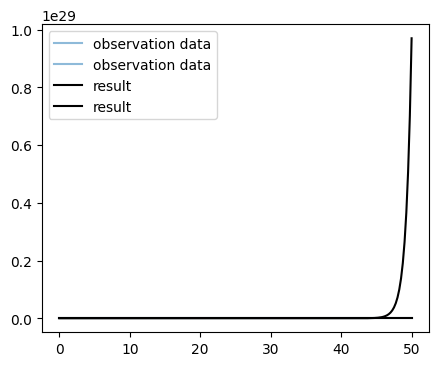

In [3]:
# Initialize the simulation object
sim = SimulationBase()

# Configure the case study
sim.config.case_study.name = "lotka_volterra_UDE_case_study"
sim.config.case_study.scenario = "UDETest"

key = jrandom.PRNGKey(5678)
data_key, model_key, loader_key = jrandom.split(key, 3)

# Add the model to the simulation
sim.model = Func({"alpha":jnp.array(1.3), "delta":jnp.array(1.8)},key=model_key)

# Define a solver
sim.solver = UDESolver

ts,ys = get_data(1, [1.3,0.9,0.8,1.8], 1, 5, 50, 201, 1, key=jr.PRNGKey(0))

# Create an xArray dataset containing the artificial data
test_data1 = xr.DataArray(ys[0,::2,0], coords={"time": ts[0::2]}).to_dataset(name="prey")
test_data2 = xr.DataArray(ys[0,:,1], coords={"time": ts}).to_dataset(name="predator")
test_data = xr.merge([test_data1, test_data2])

# Add our dataset to the simulation
sim.observations = test_data

# Add the initial condition to the simulation
sim.model_parameters["y0"] = sim.observations.sel(time = 0).drop_vars("time")

# Create an xArray dataset containing the external input data
# xin = xr.DataArray(np.zeros(201), coords={"time": ts}).to_dataset(name="x_in")

# Add external inputs to the simulation
# sim.model_parameters["x_in"] = xin

sim.config.jaxsolver.max_steps = 100000
sim.config.jaxsolver.throw_exception = True

# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator, run the simulation and obtain the results
evaluator = sim.dispatch()
evaluator()
data_res = evaluator.results

# Plot the results
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(test_data.time, test_data.prey, ls="-", color="tab:blue", alpha=.5, label ="observation data")
ax.plot(test_data.time, test_data.predator, ls="-", color="tab:blue", alpha=.5, label ="observation data")
ax.plot(data_res.time, data_res.prey, color="black", label ="result")
ax.plot(data_res.time, data_res.predator, color="black", label ="result")
ax.legend()

create a simulation with n data batches (same situation as above for x_in)

C:\Users\Markus\AppData\Local\Temp\ipykernel_14488\3215443746.py:26: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  test_data = xr.merge([test_data1, test_data2])
C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.prey = Datavariable(dimensions=['batch_id', 'time'] min=nan max=nan observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.prey = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.predator = Datavariable(dimensions

MinMaxScaler(variable=prey, min=0.3210952579975128, max=7.368402004241943)
MinMaxScaler(variable=predator, min=0.12846745550632477, max=5.574018478393555)


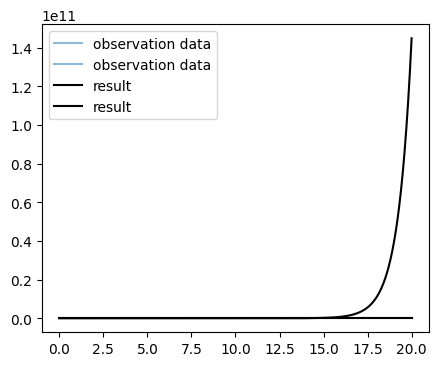

In [4]:
n = 50

# Initialize the simulation object
sim = SimulationBase()

# Configure the case study
sim.config.case_study.name = "lotka_volterra_UDE_case_study"
sim.config.case_study.scenario = "UDETest"

key = jrandom.PRNGKey(5678)
data_key, model_key, loader_key = jrandom.split(key, 3)

# Add the model to the simulation
sim.model = Func({"alpha":jnp.array(1.3), "delta":jnp.array(1.8)},key=model_key)

# Define a solver
sim.solver = UDESolver

ts,ys = get_data(n, [0.65,0.45,0.4,0.9], 5, 1, 20, 201, 0, key=jr.PRNGKey(0))

# Create an xArray dataset containing the artificial data
datasets = jnp.linspace(0,n-1,n)

test_data1 = xr.DataArray(ys[:,::2,0], coords={"batch_id": datasets, "time": ts[0::2]}).to_dataset(name="prey")
test_data2 = xr.DataArray(ys[:,:,1], coords={"batch_id": datasets, "time": ts}).to_dataset(name="predator")
test_data = xr.merge([test_data1, test_data2])

# Add our dataset to the simulation
sim.observations = test_data

# Add the initial condition to the simulation
sim.model_parameters["y0"] = sim.observations.sel(time = 0).drop_vars("time")

# Create an xArray dataset containing the external input data
# xin = xr.DataArray(np.zeros(201), coords={"time": ts}).to_dataset(name="x_in")

# Add external inputs to the simulation
# sim.model_parameters["x_in"] = xin

sim.config.jaxsolver.max_steps = 100000
sim.config.jaxsolver.throw_exception = False

# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator, run the simulation and obtain the results
evaluator = sim.dispatch()
evaluator()
data_res = evaluator.results

# Plot the results
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(test_data.time, test_data.prey.sel(batch_id = 1), ls="-", color="tab:blue", alpha=.5, label ="observation data")
ax.plot(test_data.time, test_data.predator.sel(batch_id = 1), ls="-", color="tab:blue", alpha=.5, label ="observation data")
ax.plot(data_res.time, data_res.prey.sel(batch_id = 1), color="black", label ="result")
ax.plot(data_res.time, data_res.predator.sel(batch_id = 1), color="black", label ="result")
ax.legend()

initialize inferer

In [5]:
sim.config.inference_optax.UDE_parameters.alpha = Param(value=1.3, free=False)
sim.config.inference_optax.UDE_parameters.delta = Param(value=1.8, free=True)
sim.config.inference_optax.UDE_parameters.delta.prior = "uniform(loc=1.0,scale=2.0)"

sim.config.inference_optax.MLP_weight_dist = "normal()"
sim.config.inference_optax.MLP_bias_dist = "normal()"
sim.config.inference_optax.batch_size = int(n/3)
sim.config.inference_optax.data_split = 0.8
sim.config.inference_optax.multiple_runs_target = 2
sim.config.inference_optax.multiple_runs_limit = 5

sim.set_inferer("optax")

runs inferer (implementation using the `standalone_solver` workaround)

In [6]:
sim.inferer.run()

2 of 2 runs completed: 100%|█████████▉| 2199.9999999999077/2200.0 [02:43<00:00, 13.48it/s, 0 unsuccessful runs so far]    



run number	successful?	loss

run 1		yes		0.03481396287679672
run 2		yes		0.055918872356414795


runs inferer (implementation using the standard `evaluator()` workflow)

In [ ]:
sim.inferer.run2()

1 of 2 runs completed:  50%|█████     | 1106.3999999999928/2200.0 [02:42<27:32,  1.51s/it, 0 unsuccessful runs so far]    

beautiful plots

array([<Axes: xlabel='time', ylabel='predator'>,
       <Axes: xlabel='time', ylabel='predator'>,
       <Axes: xlabel='time', ylabel='predator'>,
       <Axes: xlabel='time', ylabel='predator'>,
       <Axes: xlabel='time', ylabel='predator'>], dtype=object)

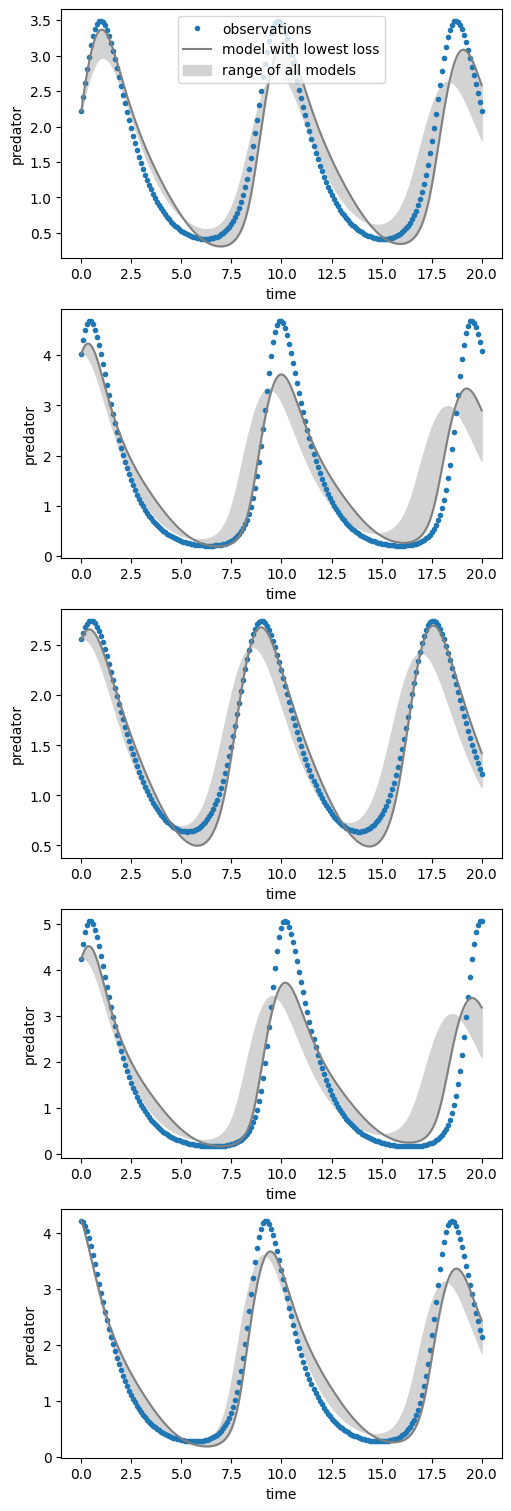

In [6]:
sim.inferer.plot_posterior_predictions("predator", "time", n=5)

save observations and config (saves into wrong directory and was only used to debug saving)

In [7]:
# Set the data paths we want to save to and create the necessary folders if they don't exist yet
import os
sim.config.create_directory("scenario", force=True)
sim.config.create_directory("results", force=True)
os.makedirs(sim.data_path, exist_ok=True)

# Save our configuration and observations
sim.save_observations(force=True)
sim.config.save(force=True)

Scenario directory exists at 'c:\Users\Markus\pymob\case_studies\lotka_volterra_UDE_case_study\scripts\case_studies\lotka_volterra_UDE_case_study\scenarios\UDETest'.
Results directory exists at 'c:\Users\Markus\pymob\case_studies\lotka_volterra_UDE_case_study\scripts\case_studies\lotka_volterra_UDE_case_study\results\UDETest'.


more or less the same for a 1-dimensional model

In [2]:
def _get_data(ts, theta, max, min, noisiness, *, key):
    """
    Returns a single time series (evaluated at the time points defined by ts) of the 
    Lotka-Volterra model with some normally-distributed noise. Initial conditions for 
    prey and predator are both chosen randomly from the range [min, max].

    Parameters
    ----------
    ts : jax.ArrayImpl
        An array containing all the time points the timeseries should be evaluated for.
    theta : list
        A list of four floats representing the parameters of the Lotka Volterra model
        [alpha, beta, gamma, delta].
    max : float
        Maximum value for the initial prey and predator values (before adding noise).
    min : float
        Minimum value for the initial prey and predator values (before adding noise).
    noisiness : float
        Scale of the normal distribution the noise is drawn from. If noisiness == 0,
        no noise is added.
    key : jax.ArrayImpl, optional
        A key used to make stochastic processes (in this case the noise values drawn 
        from a normal distribution) reproducible. If no key is provided, noise may
        differ between runs.

    Returns:
    --------
    jax.ArrayImpl
        An array containing a noisy Lotka Volterra time series, evaluated at time
        points ts.
    """
    
    y0 = jr.uniform(key, (), minval=min, maxval=max)

    def f(t, y, args):
        dYdt = theta[0]*y - theta[0]/theta[1]*y**2
        return dYdt

    solver = diffrax.Tsit5()
    dt0 = 0.1
    saveat = diffrax.SaveAt(ts=ts)
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(f), solver, ts[0], ts[-1], dt0, y0, saveat=saveat
    )
    ys = sol.ys
    noise = jr.normal(key=key, shape=(len(ts)))
    ys += noisiness * noise
    return jnp.greater(ys, jnp.zeros(ys.shape)) * ys + 1e-8

def get_data(dataset_size, theta, max, min, t_end, datapoints, noisiness, *, key):
    """
    Returns multiple time series (evaluated at the time points defined by ts) of the 
    Lotka-Volterra model with some normally-distributed noise and different initial 
    conditions for prey and predator chosen randomly from the range [min, max].

    Parameters
    ----------
    dataset_size : int
        The amount of generated time series.
    theta : list
        A list of four floats representing the parameters of the Lotka Volterra model
        [alpha, beta, gamma, delta].
    max : float
        Maximum value for the initial prey and predator values (before adding noise).
    min : float
        Minimum value for the initial prey and predator values (before adding noise).
    t_end : float
        The last point in time that the time series are supposed to contain.
    datapoints : int
        The amount of evenly-spaced datapoints each time series is supposed to contain.
    noisiness : float
        Scale of the normal distribution the noise is drawn from. If noisiness == 0,
        no noise is added.
    key : jax.Array
        A key used to make stochastic processes (in this case the noise values drawn 
        from a normal distribution) reproducible. If no key is provided, noise may
        differ between runs.

    Returns:
    --------
    jax.ArrayImpl
        An array containing multiple noisy Lotka Volterra time series, evaluated at time
        points ts.
    """

    ts = jnp.linspace(0, t_end, datapoints)
    key = jr.split(key, dataset_size)
    ys = jax.vmap(lambda key: _get_data(ts, theta, max, min, noisiness, key=key))(key)
    return ts, ys

C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.X = Datavariable(dimensions=['time'] min=7.269932270050049 max=17.866065979003906 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.X = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:579: UserWarning: The number of ODE states was not specified in the config file [simulation] > 'n_ode_states = <n>'. Extracted the return arguments ['jnp.arraydX_dt.astypefloat'] from the source code. Setting 'n_ode_states=1.
  warnings.warn(


MinMaxScaler(variable=X, min=7.269932270050049, max=17.866065979003906)


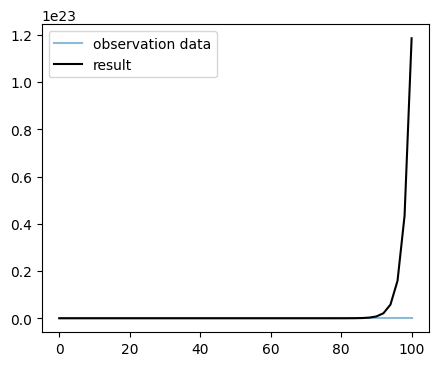

In [3]:
# Initialize the simulation object
sim = SimulationBase()

# Configure the case study
sim.config.case_study.name = "lotka_volterra_UDE_case_study"
sim.config.case_study.scenario = "UDETest1D"

key = jrandom.PRNGKey(5678)
data_key, model_key, loader_key = jrandom.split(key, 3)

# Add the model to the simulation
sim.model = Func1D({"r":jnp.array(0.5)},key=model_key)

# Define a solver
sim.solver = UDESolver

ts,ys = get_data(1, [0.5,10], 20, 0.1, 100, 101, 1, key=jr.PRNGKey(0))

# Create an xArray dataset containing the artificial data
test_data = xr.DataArray(ys[0,::2], coords={"time": ts[0::2]}).to_dataset(name="X")

# Add our dataset to the simulation
sim.observations = test_data

# Add the initial condition to the simulation
sim.model_parameters["y0"] = sim.observations.sel(time = 0).drop_vars("time")

# Create an xArray dataset containing the external input data
# xin = xr.DataArray(np.zeros(101), coords={"time": ts}).to_dataset(name="x_in")

# Add external inputs to the simulation
# sim.model_parameters["x_in"] = xin

sim.config.jaxsolver.max_steps = 100000

# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator, run the simulation and obtain the results
evaluator = sim.dispatch()
evaluator()
data_res = evaluator.results

# Plot the results
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(test_data.time, test_data.X, ls="-", color="tab:blue", alpha=.5, label ="observation data")
ax.plot(data_res.time, data_res.X, color="black", label ="result")
ax.legend()

C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.X = Datavariable(dimensions=['batch_id', 'time'] min=9.99999993922529e-09 max=19.354379653930664 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.X = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:579: UserWarning: The number of ODE states was not specified in the config file [simulation] > 'n_ode_states = <n>'. Extracted the return arguments ['jnp.arraydX_dt.astypefloat'] from the source code. Setting 'n_ode_states=1.
  warnings.warn(


MinMaxScaler(variable=X, min=9.99999993922529e-09, max=19.354379653930664)


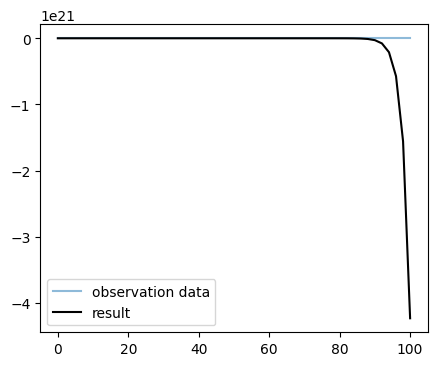

In [4]:
n = 10

# Initialize the simulation object
sim = SimulationBase()

# Configure the case study
sim.config.case_study.name = "lotka_volterra_UDE_case_study"
sim.config.case_study.scenario = "UDETest1D"

key = jrandom.PRNGKey(5678)
data_key, model_key, loader_key = jrandom.split(key, 3)

# Add the model to the simulation
sim.model = Func1D({"r":jnp.array(0.5)},key=model_key)

# Define a solver
sim.solver = UDESolver

ts,ys = get_data(n, [0.5,10], 20, 0.1, 100, 101, 1, key=jr.PRNGKey(0))

# Create an xArray dataset containing the artificial data
datasets = jnp.linspace(0,n-1,n)

test_data = xr.DataArray(ys[:,::2], coords={"batch_id": datasets, "time": ts[0::2]}).to_dataset(name="X")

# Add our dataset to the simulation
sim.observations = test_data

# Add the initial condition to the simulation
sim.model_parameters["y0"] = sim.observations.sel(time = 0).drop_vars("time")

# Create an xArray dataset containing the external input data
# xin = xr.DataArray(np.zeros(101), coords={"time": ts}).to_dataset(name="x_in")

# Add external inputs to the simulation
# sim.model_parameters["x_in"] = xin

sim.config.jaxsolver.max_steps = 100000

# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator, run the simulation and obtain the results
evaluator = sim.dispatch()
evaluator()
data_res = evaluator.results

# Plot the results
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(test_data.time, test_data.X.sel(batch_id = 1), ls="-", color="tab:blue", alpha=.5, label ="observation data")
ax.plot(data_res.time, data_res.X.sel(batch_id = 1), color="black", label ="result")
ax.legend()

In [8]:
sim.config.inference_optax.UDE_parameters.r = Param(value=0.5, free=False)

sim.config.inference_optax.MLP_weight_dist = "normal()"
sim.config.inference_optax.MLP_bias_dist = "normal()"
sim.config.inference_optax.batch_size = 5
sim.config.inference_optax.data_split = 0.8
sim.config.inference_optax.multiple_runs_target = 2
sim.config.inference_optax.multiple_runs_limit = 10

sim.set_inferer("optax")

In [10]:
sim.inferer.run()

2 of 2 runs completed: 100%|█████████▉| 2199.999999999909/2200.0 [03:33<00:00, 10.28it/s, 3 unsuccessful runs so far]     



run number	successful?	loss

run 1		no		---
run 2		no		---
run 3		yes		1.2010711431503296
run 4		no		---
run 5		yes		1.0392415523529053


In [11]:
sim.inferer.run2()

2 of 2 runs completed: 100%|█████████▉| 2199.9999999999077/2200.0 [01:48<00:00, 20.23it/s, 0 unsuccessful runs so far]    



run number	successful?	loss

run 1		yes		1.0563292503356934
run 2		yes		1.0259826183319092


array([<Axes: xlabel='time', ylabel='X'>,
       <Axes: xlabel='time', ylabel='X'>], dtype=object)

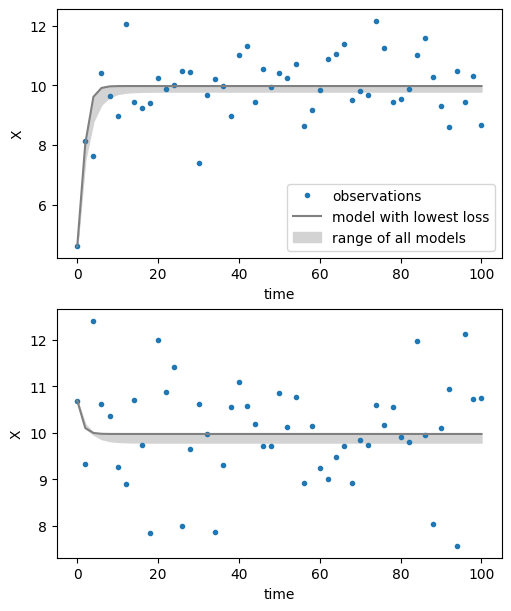

In [12]:
sim.inferer.plot_posterior_predictions("X", "time", n=2)